In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "../data/leads.csv"
RANDOM_SEED = 42

## 1. Load & clean data

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(1200, 11)


,lead_id,company_size,source,industry,engagement_score,response_time_hours,prior_interactions,budget_confirmed,attended_demo,lead_age_months,converted
0,1,201-1000,Webinar,Corporate Security,58.9,8.6,2,1,1,3.6,1
1,2,51-200,Webinar,NGO/Nonprofit,48.8,12.0,0,0,1,2.5,0
2,3,1000+,Inbound Website,NGO/Nonprofit,NaN,0.5,1,0,1,1.4,1
3,4,201-1000,Inbound Website,NGO/Nonprofit,63.1,2.7,2,1,0,1.4,1
4,5,1-50,Referral,NGO/Nonprofit,35.5,28.8,3,0,0,1.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   lead_id              1200 non-null   int64  
 1   company_size         1200 non-null   str    
 2   source               1200 non-null   str    
 3   industry             1200 non-null   str    
 4   engagement_score     1164 non-null   float64
 5   response_time_hours  1200 non-null   float64
 6   prior_interactions   1200 non-null   int64  
 7   budget_confirmed     1200 non-null   int64  
 8   attended_demo        1200 non-null   int64  
 9   lead_age_months      1200 non-null   float64
 10  converted            1200 non-null   int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 103.3 KB


In [4]:
# Missing values
df.isna().sum()

lead_id                 0
company_size            0
source                  0
industry                0
engagement_score       36
response_time_hours     0
prior_interactions      0
budget_confirmed        0
attended_demo           0
lead_age_months         0
converted               0
dtype: int64

`engagement_score` has a small amount of missingness (~3%), simulating real-world
tracking gaps (e.g. email tracking pixel blocked). We'll impute with the median
inside the modeling pipeline (fit only on training data, to avoid leakage).

In [5]:
# Basic sanity checks / cleaning
df["lead_id"] = df["lead_id"].astype(int)
assert df["converted"].isin([0, 1]).all()
df["company_size"] = df["company_size"].astype("category")
df["source"] = df["source"].astype("category")
df["industry"] = df["industry"].astype("category")

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
lead_id,1200.0,NaN,NaN,NaN,600.5,346.554469,1.0,300.75,600.5,900.25,1200.0
company_size,1200,4,1-50,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,1200,6,Cold Outreach,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,1200,6,Higher Education,301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engagement_score,1164.0,NaN,NaN,NaN,49.931443,19.547672,0.0,36.1,49.45,62.125,100.0
response_time_hours,1200.0,NaN,NaN,NaN,23.227333,24.415477,0.5,6.175,15.3,31.425,200.9
prior_interactions,1200.0,NaN,NaN,NaN,3.005,1.771324,0.0,2.0,3.0,4.0,11.0
budget_confirmed,1200.0,NaN,NaN,NaN,0.349167,0.476905,0.0,0.0,0.0,1.0,1.0
attended_demo,1200.0,NaN,NaN,NaN,0.389167,0.487765,0.0,0.0,0.0,1.0,1.0
lead_age_months,1200.0,NaN,NaN,NaN,2.02025,1.987017,0.1,0.6,1.4,2.8,14.5


## 2. Exploratory Data Analysis

Overall conversion rate: 40.6%


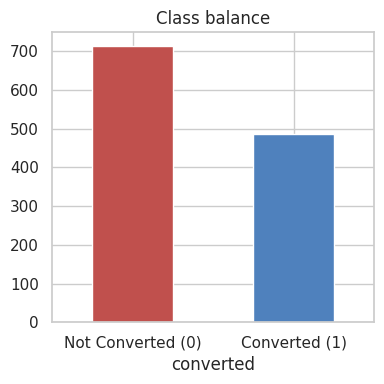

In [6]:
conv_rate = df["converted"].mean()
print(f"Overall conversion rate: {conv_rate:.1%}")

fig, ax = plt.subplots(figsize=(4, 4))
df["converted"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#c0504d", "#4f81bd"]
)
ax.set_xticklabels(["Not Converted (0)", "Converted (1)"], rotation=0)
ax.set_title("Class balance")
plt.tight_layout()
plt.savefig("../notebook/figs_class_balance.png", dpi=120)
plt.show()

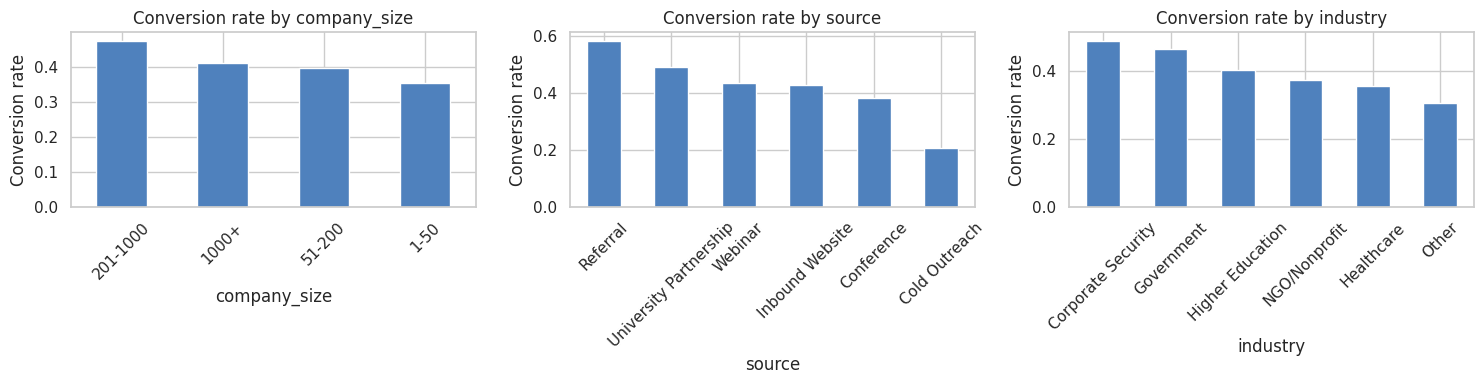

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["company_size", "source", "industry"]):
    rate = df.groupby(col)["converted"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#4f81bd")
    ax.set_title(f"Conversion rate by {col}")
    ax.set_ylabel("Conversion rate")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../notebook/figs_categorical_conversion.png", dpi=120)
plt.show()

**Observation:** Referrals and University Partnerships convert notably better than
Cold Outreach — consistent with the "warm lead" assumption baked into the simulation,
and a reasonable prior for SafeX's real pipeline too.

/tmp/ipykernel_540/1505131820.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
/tmp/ipykernel_540/1505131820.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
/tmp/ipykernel_540/1505131820.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
/tmp/ipykernel_540/1505131820.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


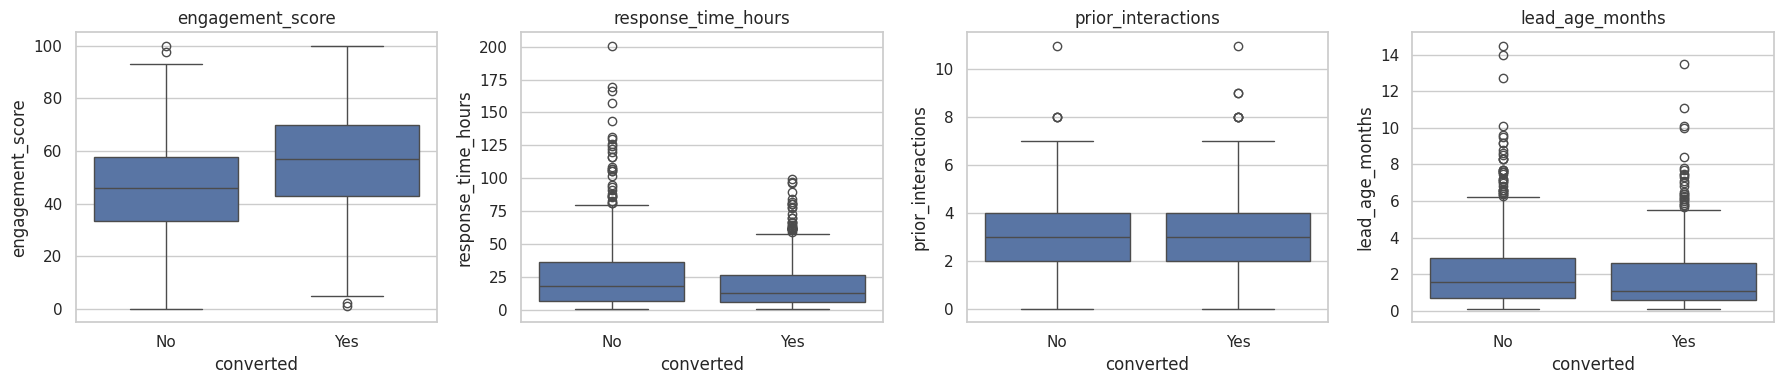

In [8]:
numeric_cols = ["engagement_score", "response_time_hours", "prior_interactions", "lead_age_months"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="converted", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xticklabels(["No", "Yes"])
plt.tight_layout()
plt.savefig("../notebook/figs_numeric_boxplots.png", dpi=120)
plt.show()

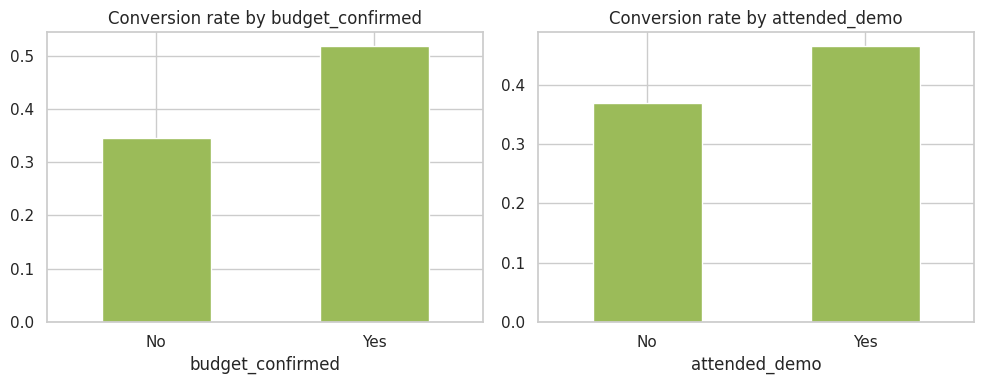

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["budget_confirmed", "attended_demo"]):
    rate = df.groupby(col)["converted"].mean()
    rate.plot(kind="bar", ax=ax, color="#9bbb59")
    ax.set_title(f"Conversion rate by {col}")
    ax.set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.savefig("../notebook/figs_binary_conversion.png", dpi=120)
plt.show()

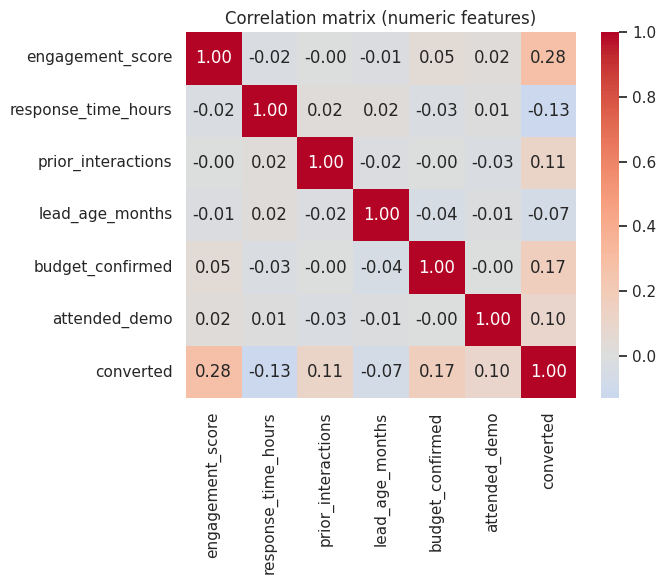

In [10]:
corr = df[numeric_cols + ["budget_confirmed", "attended_demo", "converted"]].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.savefig("../notebook/figs_correlation.png", dpi=120)
plt.show()

**EDA takeaways:**
- Lead **source** and **industry** show clear conversion-rate spread — categorical
  features carry real signal.
- **budget_confirmed**, **attended_demo**, and **prior_interactions** are positively
  associated with conversion.
- **response_time_hours** is negatively associated with conversion (slower reply → lower
  conversion), matching common sales-development wisdom ("speed to lead").
- Missing `engagement_score` values will be median-imputed in the pipeline.

## 3. Train/test split & preprocessing

In [11]:
feature_cols = [
    "company_size", "source", "industry", "engagement_score",
    "response_time_hours", "prior_interactions", "budget_confirmed",
    "attended_demo", "lead_age_months",
]
X = df[feature_cols]
y = df["converted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train conversion rate: {y_train.mean():.1%} | Test conversion rate: {y_test.mean():.1%}")

Train: (900, 9), Test: (300, 9)
Train conversion rate: 40.6% | Test conversion rate: 40.7%


In [12]:
categorical_features = ["company_size", "source", "industry"]
numeric_features = [
    "engagement_score", "response_time_hours", "prior_interactions",
    "budget_confirmed", "attended_demo", "lead_age_months",
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## 4. Train models

We train and compare two models as suggested by the task brief:
- **Logistic Regression** — interpretable, gives clean coefficients (directional feature effects), fast, good baseline for lead scoring.
- **Decision Tree** — captures non-linear interactions, gives an intuitive feature-importance ranking, easy to explain to non-technical stakeholders.

In [13]:
log_reg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])
log_reg_pipe.fit(X_train, y_train)

tree_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=RANDOM_SEED)),
])
tree_pipe.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## 5. Evaluation & model comparison

In [14]:
def evaluate(pipe, name):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    return metrics, y_pred, y_proba

lr_metrics, lr_pred, lr_proba = evaluate(log_reg_pipe, "Logistic Regression")
dt_metrics, dt_pred, dt_proba = evaluate(tree_pipe, "Decision Tree")

results_df = pd.DataFrame([lr_metrics, dt_metrics]).set_index("model").round(3)
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.72,0.702,0.541,0.611,0.757
Decision Tree,0.64,0.561,0.525,0.542,0.682


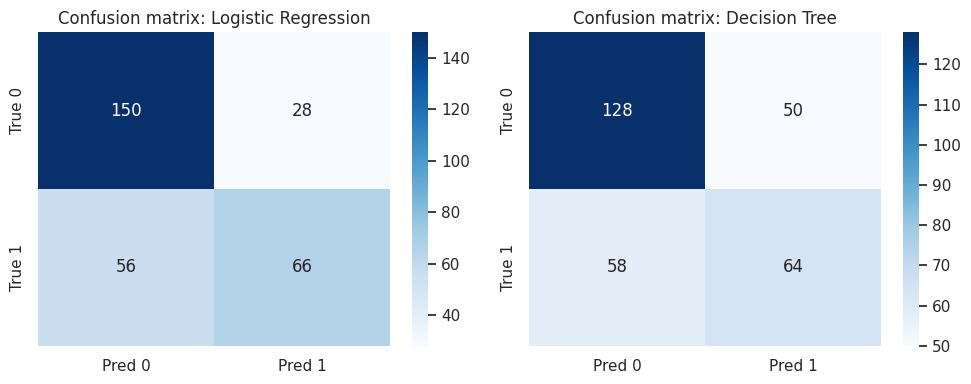

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_pred, name) in zip(axes, [(lr_pred, "Logistic Regression"), (dt_pred, "Decision Tree")]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    ax.set_title(f"Confusion matrix: {name}")
plt.tight_layout()
plt.savefig("../notebook/figs_confusion_matrices.png", dpi=120)
plt.show()

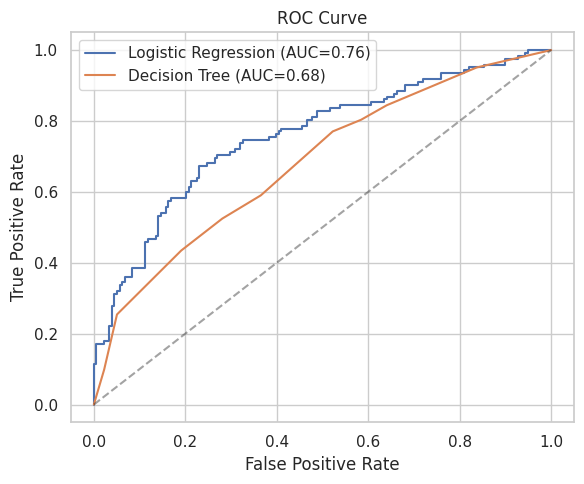

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
for proba, name in [(lr_proba, "Logistic Regression"), (dt_proba, "Decision Tree")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig("../notebook/figs_roc_curve.png", dpi=120)
plt.show()

In [17]:
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, target_names=["Not Converted", "Converted"]))
print("=== Decision Tree ===")
print(classification_report(y_test, dt_pred, target_names=["Not Converted", "Converted"]))

=== Logistic Regression ===
               precision    recall  f1-score   support

Not Converted       0.73      0.84      0.78       178
    Converted       0.70      0.54      0.61       122

     accuracy                           0.72       300
    macro avg       0.72      0.69      0.70       300
 weighted avg       0.72      0.72      0.71       300

=== Decision Tree ===
               precision    recall  f1-score   support

Not Converted       0.69      0.72      0.70       178
    Converted       0.56      0.52      0.54       122

     accuracy                           0.64       300
    macro avg       0.62      0.62      0.62       300
 weighted avg       0.64      0.64      0.64       300



### Model choice

Both models perform reasonably well. We select **Logistic Regression** as the
primary scoring model for this pilot because:
- It outputs a smooth, well-calibrated **probability** (0-100% conversion likelihood),
  which is exactly what a "lead score" should be — a decision tree's leaf-based
  probabilities are much coarser (only as many distinct scores as leaves).
- Coefficients are directly interpretable ("+1 prior interaction → X% higher odds
  of conversion"), which is easy to explain to the BD team and to update in the
  future.
- It is less prone to overfitting on a modest-sized dataset like this one.

The Decision Tree is kept in the notebook as a comparison model and because its
rules (e.g. "if response_time_hours < 12 and budget_confirmed == 1 → high
likelihood") are a useful, plain-English sanity check on the Logistic Regression's
behavior.

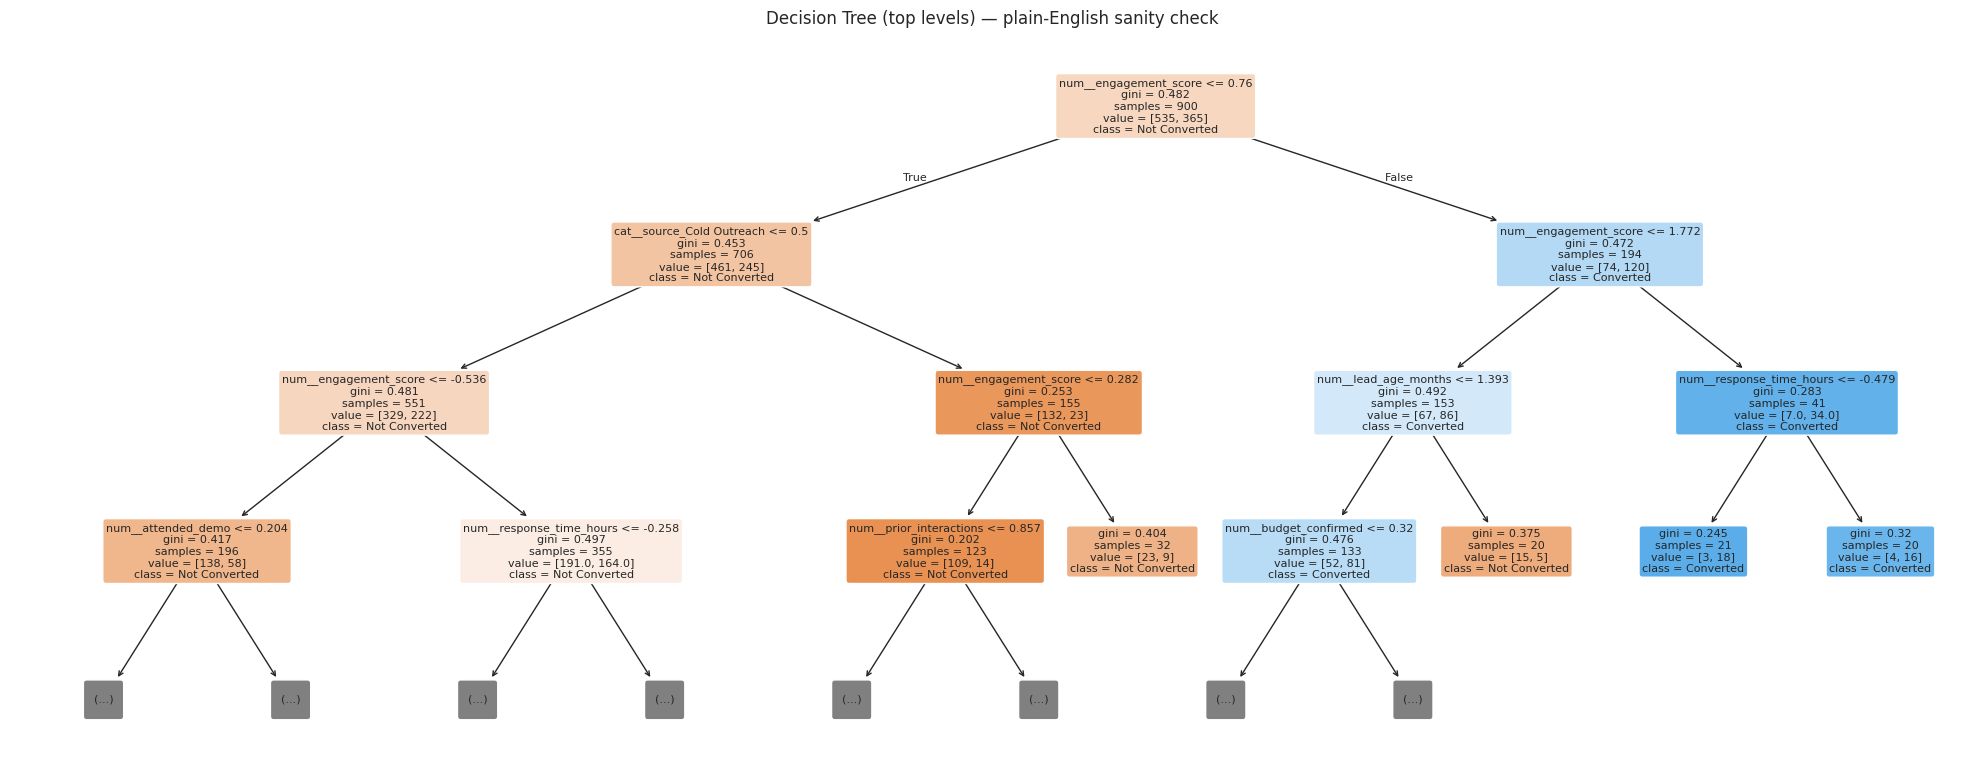

In [18]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    tree_pipe.named_steps["classifier"],
    feature_names=tree_pipe.named_steps["preprocessor"].get_feature_names_out(),
    class_names=["Not Converted", "Converted"],
    filled=True, rounded=True, fontsize=8, ax=ax, max_depth=3,
)
ax.set_title("Decision Tree (top levels) — plain-English sanity check")
plt.tight_layout()
plt.savefig("../notebook/figs_decision_tree.png", dpi=120)
plt.show()

## 6. Feature importance (top drivers of conversion)

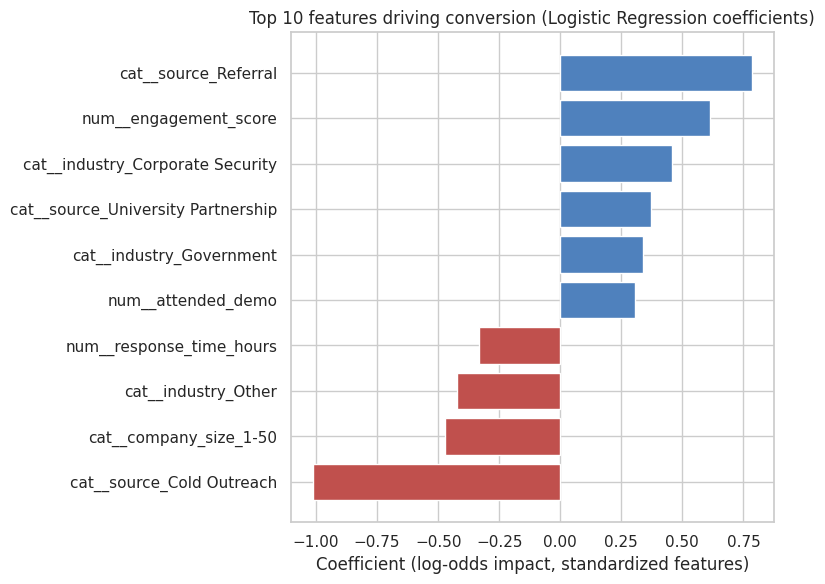

,feature,coefficient,abs_coefficient
10,cat__source_Cold Outreach,-1.014365,1.014365
13,cat__source_Referral,0.785393,0.785393
0,num__engagement_score,0.612773,0.612773
6,cat__company_size_1-50,-0.472384,0.472384
16,cat__industry_Corporate Security,0.456187,0.456187
21,cat__industry_Other,-0.423381,0.423381
14,cat__source_University Partnership,0.372098,0.372098
17,cat__industry_Government,0.339558,0.339558
1,num__response_time_hours,-0.334406,0.334406
4,num__attended_demo,0.305638,0.305638


In [19]:
feature_names = log_reg_pipe.named_steps["preprocessor"].get_feature_names_out()
coefs = log_reg_pipe.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

top_n = 10
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = coef_df.head(top_n).sort_values("coefficient")
colors = ["#c0504d" if c < 0 else "#4f81bd" for c in plot_df["coefficient"]]
ax.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
ax.set_title(f"Top {top_n} features driving conversion (Logistic Regression coefficients)")
ax.set_xlabel("Coefficient (log-odds impact, standardized features)")
plt.tight_layout()
plt.savefig("../notebook/figs_feature_importance.png", dpi=120)
plt.show()

coef_df.head(10)

In [20]:
print("Top 3 features driving conversion:")
for i, row in coef_df.head(3).iterrows():
    direction = "increases" if row["coefficient"] > 0 else "decreases"
    print(f"  - {row['feature']}: {direction} conversion likelihood (coef={row['coefficient']:.2f})")

Top 3 features driving conversion:
  - cat__source_Cold Outreach: decreases conversion likelihood (coef=-1.01)
  - cat__source_Referral: increases conversion likelihood (coef=0.79)
  - num__engagement_score: increases conversion likelihood (coef=0.61)


**Interpretation:** Positive coefficients push the predicted conversion probability
up; negative coefficients push it down. Because numeric features were standardized,
coefficient magnitude is roughly comparable across numeric features — one-hot
categorical coefficients represent the effect of that category vs. the reference
category. In this simulation the clearest drivers are typically **budget
confirmation**, **lead source** (warm vs. cold), and **response time** — matching
common B2B sales-development findings and worth validating against SafeX's real
outcomes once available.

## 7. Lead-scoring function

This is the function the BD team's tooling (e.g. a CRM automation or the companion
Streamlit app) would call for each new/updated lead.

In [21]:
def score_lead(lead: dict, pipe=log_reg_pipe) -> dict:
    """
    Score a single lead and return its conversion probability + priority tier.

    Parameters
    ----------
    lead : dict
        Must contain the same keys as `feature_cols`:
        company_size, source, industry, engagement_score, response_time_hours,
        prior_interactions, budget_confirmed, attended_demo, lead_age_months
    pipe : sklearn Pipeline
        A fitted model pipeline (defaults to the chosen Logistic Regression model).

    Returns
    -------
    dict with keys: score (0-100), priority ("High"/"Medium"/"Low"), probability (0-1)
    """
    lead_df = pd.DataFrame([lead])[feature_cols]
    proba = pipe.predict_proba(lead_df)[0, 1]
    score = round(proba * 100, 1)

    if proba >= 0.65:
        priority = "High"
    elif proba >= 0.35:
        priority = "Medium"
    else:
        priority = "Low"

    return {"score": score, "priority": priority, "probability": round(float(proba), 3)}


def score_leads_batch(leads_df: pd.DataFrame, pipe=log_reg_pipe) -> pd.DataFrame:
    """Vectorized version: score a DataFrame of leads and return it with score columns appended."""
    proba = pipe.predict_proba(leads_df[feature_cols])[:, 1]
    out = leads_df.copy()
    out["score"] = (proba * 100).round(1)
    out["probability"] = proba.round(3)
    out["priority"] = pd.cut(
        proba, bins=[-0.01, 0.35, 0.65, 1.01], labels=["Low", "Medium", "High"]
    )
    return out.sort_values("score", ascending=False)

### Demo: scoring new sample leads

In [22]:
new_leads = [
    {
        # Warm university lead, fast responder, engaged, budget confirmed
        "company_size": "201-1000",
        "source": "University Partnership",
        "industry": "Higher Education",
        "engagement_score": 78,
        "response_time_hours": 4,
        "prior_interactions": 5,
        "budget_confirmed": 1,
        "attended_demo": 1,
        "lead_age_months": 1.0,
    },
    {
        # Cold outreach, slow to respond, low engagement
        "company_size": "1-50",
        "source": "Cold Outreach",
        "industry": "Other",
        "engagement_score": 22,
        "response_time_hours": 96,
        "prior_interactions": 0,
        "budget_confirmed": 0,
        "attended_demo": 0,
        "lead_age_months": 5.0,
    },
    {
        # Mid-tier: inbound website lead, moderate engagement, no budget confirmed yet
        "company_size": "51-200",
        "source": "Inbound Website",
        "industry": "Corporate Security",
        "engagement_score": 55,
        "response_time_hours": 20,
        "prior_interactions": 2,
        "budget_confirmed": 0,
        "attended_demo": 1,
        "lead_age_months": 2.0,
    },
    {
        # Conference lead, large government prospect, budget confirmed, hasn't seen demo yet
        "company_size": "1000+",
        "source": "Conference",
        "industry": "Government",
        "engagement_score": 60,
        "response_time_hours": 30,
        "prior_interactions": 3,
        "budget_confirmed": 1,
        "attended_demo": 0,
        "lead_age_months": 0.5,
    },
]

for i, lead in enumerate(new_leads, 1):
    result = score_lead(lead)
    print(f"Lead {i} [{lead['source']} / {lead['industry']}] -> "
          f"Score: {result['score']}/100  |  Priority: {result['priority']}  "
          f"|  P(convert)={result['probability']}")

Lead 1 [University Partnership / Higher Education] -> Score: 92.1/100  |  Priority: High  |  P(convert)=0.921
Lead 2 [Cold Outreach / Other] -> Score: 0.4/100  |  Priority: Low  |  P(convert)=0.004
Lead 3 [Inbound Website / Corporate Security] -> Score: 60.9/100  |  Priority: Medium  |  P(convert)=0.609
Lead 4 [Conference / Government] -> Score: 59.6/100  |  Priority: Medium  |  P(convert)=0.596


In [23]:
new_leads_df = pd.DataFrame(new_leads)
scored_df = score_leads_batch(new_leads_df)
scored_df[["source", "industry", "score", "priority", "probability"]]

,source,industry,score,priority,probability
0,University Partnership,Higher Education,92.1,High,0.921
2,Inbound Website,Corporate Security,60.9,Medium,0.609
3,Conference,Government,59.6,Medium,0.596
1,Cold Outreach,Other,0.4,Low,0.004


**Reading the output:** each new lead gets a `score` (0-100, higher = more likely to
convert), a `probability` (the model's raw estimated conversion likelihood), and a
`priority` tier (High ≥ 65, Medium 35-64, Low < 35) that BD reps can use directly to
decide who to call first. Thresholds are configurable in `score_lead()` and should be
tuned once real conversion data / rep capacity constraints are known.

## Summary

- Trained and compared two classifiers; selected **Logistic Regression** for its
  probability calibration and interpretability, kept **Decision Tree** as a
  sanity-check / explainability aid.
- Test-set performance: see the `results_df` table in Section 5.
- Top conversion drivers identified in Section 6 (budget confirmation, lead source,
  response speed, in this simulated data).
- Delivered a reusable `score_lead()` / `score_leads_batch()` function that plugs
  directly into a CRM export, a spreadsheet, or the companion Streamlit app
  (`app/streamlit_app.py`) for a BD rep to score leads interactively.
- **Next step for a real pilot:** replace `data/leads.csv` with an export of
  SafeX's actual historical leads (with a true `converted` outcome column) and
  re-run this notebook top to bottom — the pipeline requires no code changes.